In [1]:
import json
import struct
import numpy as np
import matplotlib.pyplot as plt
import photonforge as pf
import siepic_forge as siepic
import luxtelligence_lnoi400_forge as lxt
import tidy3d as td

td.config.logging_level = "ERROR"

# Set up technologies
siepic_tech = siepic.ebeam()
basic_tech = pf.basic_technology()
lxt_tech = lxt.lnoi400()
pf.config.default_technology = siepic_tech

# Initialize live viewer for real-time visualization
from photonforge.live_viewer import LiveViewer
viewer = LiveViewer()

# Define simulation parameters
wavelengths = np.linspace(1.53, 1.57, 101)
freqs = pf.C_0 / wavelengths

Starting live viewer at http://localhost:5001


In [2]:
siepic.component_names

{'ANT_MMI_1x2_te1550_3dB_BB',
 'GC_SiN_TE_1310_8degOxide_BB',
 'GC_SiN_TE_1550_8degOxide_BB',
 'GC_TE_1310_8degOxide_BB',
 'GC_TE_1550_8degOxide_BB',
 'GC_TM_1310_8degOxide_BB',
 'GC_TM_1550_8degOxide_BB',
 'crossing_horizontal',
 'crossing_manhattan',
 'ebeam_BondPad',
 'ebeam_DC_2-1_te895',
 'ebeam_DC_te895',
 'ebeam_MMI_2x2_5050_te1310',
 'ebeam_Polarizer_TM_1550_UQAM',
 'ebeam_YBranch_895',
 'ebeam_YBranch_te1310',
 'ebeam_adiabatic_te1550',
 'ebeam_adiabatic_tm1550',
 'ebeam_bdc_te1550',
 'ebeam_crossing4',
 'ebeam_gc_te1550',
 'ebeam_gc_te895',
 'ebeam_gc_tm1550',
 'ebeam_routing_taper_te1550_w=500nm_to_w=3000nm_L=20um',
 'ebeam_routing_taper_te1550_w=500nm_to_w=3000nm_L=40um',
 'ebeam_splitter_swg_assist_te1310',
 'ebeam_splitter_swg_assist_te1550',
 'ebeam_terminator_SiN_1550',
 'ebeam_terminator_SiN_te895',
 'ebeam_terminator_te1310',
 'ebeam_terminator_te1550',
 'ebeam_terminator_tm1550',
 'ebeam_y_1550',
 'ebeam_y_adiabatic',
 'ebeam_y_adiabatic_500pin',
 'taper_SiN_750_3000

In [3]:
siepic.component("taper_si_simm_1310")

In [4]:
@pf.parametric_component
def parametric_ring_resonator(*, port_spec, coupling_distance=0.7, radius=5, bus_length=5, coupling_length=0, euler_fraction=0, model_kwargs={}):
    if isinstance(port_spec, str):
        port_spec = pf.config.default_technology.ports[port_spec]

    ring_coupler = pf.parametric.ring_coupler(
        port_spec=port_spec, 
        coupling_distance=coupling_distance, 
        radius=radius,
        bus_length=bus_length,
        coupling_length=coupling_length,
        euler_fraction=euler_fraction
    )

    ring_resonator = pf.Component("ring_resonator")
    
    bottom_coupler_ref = ring_resonator.add_reference(ring_coupler)
    top_coupler_ref = ring_resonator.add_reference(ring_coupler)
    
    bottom_coupler_ref.connect("P1", top_coupler_ref["P3"])
    bottom_coupler_ref.connect("P3", top_coupler_ref["P1"])

    ring_resonator.add_port(ring_resonator.detect_ports([port_spec]))
    ring_resonator.add_model(pf.Tidy3DModel(**model_kwargs), "Tidy3D")
    ring_resonator.add_model(pf.CircuitModel(), "Circuit")

    return ring_resonator

# viewer(parametric_ring_resonator(port_spec="Rib_TE_1550_500"))

In [5]:
class ThermalModel(pf.Model):
    def __init__(self, n_complex, voltage=0, coefficient=3e-4):
        super().__init__(
            n_complex=n_complex,
            voltage=voltage,
            coefficient=coefficient,
        )
        self.n_complex = np.array(n_complex, ndmin=2)
        self.voltage = voltage
        self.coefficient = coefficient

    def __copy__(self):
        return ThermalModel(self.n_complex, self.voltage, self.coefficient)

    def __deepcopy__(self, memo=None):
        # n_complex is an array, so we want to make sure to create a deep copy of it.
        # Other values (voltage and coefficient) are immutable (floats), so we can use them directly.
        return ThermalModel(self.n_complex.copy(), self.voltage, self.coefficient)

    def __repr__(self):
        return f"ThermalModel({self.n_complex!r}, {self.voltage!r}, {self.coefficient!r})"

    def __str__(self):
        return f"ThermalModel at {self.voltage} V"

    @property
    def as_bytes(self):
        coeffs = struct.pack("<2d", self.voltage, self.coefficient)
        shape = struct.pack("<2l", *self.n_complex.shape)
        n_data = self.n_complex.astype(complex).tobytes()
        # Add version 0 as first byte
        return b"\x00" + coeffs + shape + n_data

    @classmethod
    def from_bytes(cls, byte_repr):
        version = byte_repr[0]
        if version != 0:
            raise RuntimeError(f"Incompatible version for ThermalModel: {version}")

        byte_repr = byte_repr[1:]
        fmt = "<2d2l"
        head_len = struct.calcsize(fmt)
        voltage, coefficient, rows, cols = struct.unpack(fmt, byte_repr[:head_len])

        byte_repr = byte_repr[head_len:]
        n_complex = np.frombuffer(byte_repr, dtype=complex).reshape((rows, cols))

        return cls(n_complex, voltage, coefficient)

    @pf.cache_s_matrix
    def start(self, component, frequencies, voltage=None, **kwargs):
        # Allow overriding voltage as an `s_matrix` kwarg too
        if voltage is None:
            voltage = self.voltage
        n_complex = self.n_complex + self.coefficient * voltage**2
        wg_model = pf.WaveguideModel(n_complex)
        return wg_model.start(component, frequencies, **kwargs)


pf.register_model_class(ThermalModel)

In [6]:
@pf.parametric_component
def create_tunable_resonator(*, name="MRR", port_spec, coupling_distance=0.7, radius=5, ps_length=5):
    if isinstance(port_spec, str):
        port_spec = pf.config.default_technology.ports[port_spec]

    # Bend and Straight waveguide to form the microring
    phase_shifter = pf.parametric.straight(name=f"{name}_ps", port_spec=port_spec, length=ps_length)
    straight = pf.parametric.straight(port_spec=port_spec, length=ps_length)
    coupler = pf.parametric.ring_coupler(port_spec=port_spec, coupling_distance=coupling_distance, radius=radius)

    # Solve for the port mode of the waveguide and extract the complex refractive index
    alpha = 10
    kappa = (alpha * wavelengths * 1e-4 * np.log(10)) / (40 * np.pi)
    mode_solver = pf.port_modes(port=phase_shifter.ports["P0"], frequencies=freqs)
    n_complex = mode_solver.data.n_complex.values.T + 1j * kappa  # add propagation loss

    thermal_model = ThermalModel(n_complex=n_complex)
    phase_shifter.add_model(thermal_model, "Thermal")

    tunable_resonator = pf.Component("tunable_resonator")

    # form main microring structure
    cp1_ref = tunable_resonator.add_reference(coupler)
    cp2_ref = tunable_resonator.add_reference(coupler)
    ps1_ref = tunable_resonator.add_reference(phase_shifter)
    ps2_ref = tunable_resonator.add_reference(phase_shifter)
    # st1_ref = tunable_resonator.add_reference(straight)

    ps1_ref.connect("P0", cp1_ref["P1"])
    # st1_ref.connect("P0", cp1_ref["P3"])
    ps2_ref.connect("P0", cp1_ref["P3"])
    cp2_ref.connect("P3", ps1_ref["P1"])

    # Define the heater and electrical path
    terminal_width = 10

    # ## HORIZONTAL HEATERS
    # heater = (
    #     pf.Path((-radius-1.5, ps_length/2), ps_length)
    #     .segment((radius+1.5, ps_length/2), ps_length)
    # )

    # terminal_vp = (
    #     pf.Path((-radius-1.5 - terminal_width, ps_length/2), terminal_width)
    #     .segment((-radius-1.5, ps_length/2), terminal_width)
    # )

    # terminal_vn = (
    #     pf.Path((radius+1.5, ps_length/2), terminal_width)
    #     .segment((radius+1.5 + terminal_width, ps_length/2), terminal_width)
    # )

    # tunable_resonator.add((11,0), heater)
    # tunable_resonator.add((12,0), terminal_vp)
    # tunable_resonator.add((12,0), terminal_vn)
    # tunable_resonator.add_terminal(pf.Terminal((12,0), terminal_vp), "VP")
    # tunable_resonator.add_terminal(pf.Terminal((12,0), terminal_vn), "VN")

    ## VERTICAL HEATERS
    heater_left = (
        pf.Path((-radius, 0), 3)
        .segment((-radius, ps_length), 3)
    )

    heater_right = (
        pf.Path((radius, 0), 3)
        .segment((radius, ps_length), 3)
    )

    terminal_vp = (
        pf.Path((0, ps_length+radius), 2*radius+terminal_width)
        .segment((0, ps_length+radius+terminal_width), 2*radius+terminal_width)
    )

    routing_top_left = (
        pf.Path((-radius, ps_length+radius), terminal_width)
        .segment((-radius, ps_length), 3)
    )

    routing_bott_left = (
        pf.Path((-radius, -radius), terminal_width)
        .segment((-radius, 0), 3)
    )

    terminal_vn = (
        pf.Path((0, -radius), 2*radius+terminal_width)
        .segment((0, -radius-terminal_width), 2*radius+terminal_width)
    )

    routing_top_right = (
        pf.Path((radius, ps_length+radius), terminal_width)
        .segment((radius, ps_length), 3)
    )

    routing_bott_right = (
        pf.Path((radius, -radius), terminal_width)
        .segment((radius, 0), 3)
    )

    tunable_resonator.add((11,0), heater_left)
    tunable_resonator.add((11,0), heater_right)
    tunable_resonator.add((12,0), terminal_vp)
    tunable_resonator.add((12,0), terminal_vn)
    tunable_resonator.add((12,0), routing_top_left)
    tunable_resonator.add((12,0), routing_bott_left)
    tunable_resonator.add((12,0), routing_top_right)
    tunable_resonator.add((12,0), routing_bott_right)
    tunable_resonator.add_terminal(pf.Terminal((12,0), terminal_vp), "VP")
    tunable_resonator.add_terminal(pf.Terminal((12,0), terminal_vn), "VN")


    ## COMPONENT MODELS
    tunable_resonator.add_port(tunable_resonator.detect_ports([port_spec]))
    tunable_resonator.add_model(pf.CircuitModel(), "CircuitModel")

    port_symmetries = [
        ("P2", "P3", "P0", "P1"),
        ("P1", "P0", "P3", "P2"),
    ]

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )

    tunable_resonator.add_model(pf.Tidy3DModel(port_symmetries=port_symmetries, monitors=[field_monitor]), "Tidy3DModel")

    return tunable_resonator

tunable_resonator = create_tunable_resonator(port_spec="Rib_TE_1550_500", radius=7, coupling_distance=0.6, ps_length=6)
# viewer(tunable_resonator)

Loading cached simulation from C:\Users\ASUS\.tidy3d\pf_cache\VON\ms_info-R27ISU77BQ5WMHN2UYHOYDRCUU24MQCYZA4HFGIWYAQ3DHQAF6FA.json.
Progress: 100%


Progress: 100%


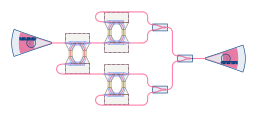

In [18]:
alice_top = pf.Component("alice_top")
# ring_resonator = parametric_ring_resonator(port_spec="Rib_TE_1550_500", radius=10, bus_length=15, coupling_distance=0.6)
tunable_resonator = create_tunable_resonator(port_spec="Rib_TE_1550_500", radius=7, coupling_distance=0.6, ps_length=6)
straight = pf.parametric.straight(port_spec="TE_1550_500", length=26)
half_straight = pf.parametric.straight(port_spec="TE_1550_500", length=13)
# quarter_straight = pf.parametric.straight(port_spec="TE_1550_500", length=5)
y_branch = siepic.component("ebeam_y_1550")
grating_coupler = siepic.component("ebeam_gc_te1550")
bend = pf.parametric.bend(port_spec="TE_1550_500", radius=5, euler_fraction=0.5, angle=180)
sbend_top = pf.parametric.s_bend(port_spec="TE_1550_500", length=30, offset=-10.85, euler_fraction=0.5)
sbend_bottom = pf.parametric.s_bend(port_spec="TE_1550_500", length=30, offset=10.85, euler_fraction=0.5)
wider_sbend_top = pf.parametric.s_bend(port_spec="TE_1550_500", length=45, offset=-24.45, euler_fraction=0.5)
wider_sbend_bottom = pf.parametric.s_bend(port_spec="TE_1550_500", length=45, offset=24.45, euler_fraction=0.5)
trans = pf.parametric.transition(port_spec1="TE_1550_500", port_spec2="Rib_TE_1550_500", length=5, constant_length=0.5)

gc1_ref = alice_top.add_reference(grating_coupler)
gc2_ref = alice_top.add_reference(grating_coupler)

# rr1_ref = alice_top.add_reference(ring_resonator)
# rr2_ref = alice_top.add_reference(ring_resonator)
# rr3_ref = alice_top.add_reference(ring_resonator)

tr1_ref = alice_top.add_reference(tunable_resonator)
tr2_ref = alice_top.add_reference(tunable_resonator)
tr3_ref = alice_top.add_reference(tunable_resonator)

st1_ref = alice_top.add_reference(straight)
st2_ref = alice_top.add_reference(straight)
st3_ref = alice_top.add_reference(straight)
# st4_ref = alice_top.add_reference(straight)

hst1_ref = alice_top.add_reference(half_straight)
hst2_ref = alice_top.add_reference(half_straight)
hst3_ref = alice_top.add_reference(half_straight)
hst4_ref = alice_top.add_reference(half_straight)
hst5_ref = alice_top.add_reference(half_straight)
hst6_ref = alice_top.add_reference(half_straight)
hst7_ref = alice_top.add_reference(half_straight)
hst8_ref = alice_top.add_reference(half_straight)

# qst1_ref = alice_top.add_reference(quarter_straight)
# qst2_ref = alice_top.add_reference(quarter_straight)
# qst3_ref = alice_top.add_reference(quarter_straight)
# qst4_ref = alice_top.add_reference(quarter_straight)
# qst5_ref = alice_top.add_reference(quarter_straight)
# qst6_ref = alice_top.add_reference(quarter_straight)
# qst7_ref = alice_top.add_reference(quarter_straight)
# qst8_ref = alice_top.add_reference(quarter_straight)
# qst9_ref = alice_top.add_reference(quarter_straight)
# qst10_ref = alice_top.add_reference(quarter_straight)
# qst11_ref = alice_top.add_reference(quarter_straight)
# qst12_ref = alice_top.add_reference(quarter_straight)
# qst13_ref = alice_top.add_reference(quarter_straight)

bend1_ref = alice_top.add_reference(bend)
bend2_ref = alice_top.add_reference(bend)
bend3_ref = alice_top.add_reference(bend)

# sbt1_ref = alice_top.add_reference(sbend_top)
# sbt2_ref = alice_top.add_reference(sbend_top)
# sbt3_ref = alice_top.add_reference(sbend_top)

# sbb1_ref = alice_top.add_reference(sbend_bottom)
# sbb2_ref = alice_top.add_reference(sbend_bottom)
# sbb3_ref = alice_top.add_reference(sbend_bottom)

# wsbt1_ref = alice_top.add_reference(wider_sbend_top)
# wsbt2_ref = alice_top.add_reference(wider_sbend_top)
# wsbt3_ref = alice_top.add_reference(wider_sbend_top)

# wsbb1_ref = alice_top.add_reference(wider_sbend_bottom)
# wsbb2_ref = alice_top.add_reference(wider_sbend_bottom)
# wsbb3_ref = alice_top.add_reference(wider_sbend_bottom)

y1_ref = alice_top.add_reference(y_branch)
y2_ref = alice_top.add_reference(y_branch)
y3_ref = alice_top.add_reference(y_branch)

trans1_ref = alice_top.add_reference(trans)
trans2_ref = alice_top.add_reference(trans)
trans3_ref = alice_top.add_reference(trans)
trans4_ref = alice_top.add_reference(trans)
trans5_ref = alice_top.add_reference(trans)
trans6_ref = alice_top.add_reference(trans)
trans7_ref = alice_top.add_reference(trans)
trans8_ref = alice_top.add_reference(trans)
trans9_ref = alice_top.add_reference(trans)
# trans10_ref = alice_top.add_reference(trans)

#Grating Coupler, Resonator 1
hst1_ref.connect("P0",gc1_ref["P0"])
trans1_ref.connect("P0",hst1_ref["P1"])
tr1_ref.connect("P1",trans1_ref["P1"])

#Resonator 2 (atas), Rotator 90, Y Branch 1
trans2_ref.connect("P1",tr1_ref["P3"])
hst2_ref.connect("P0",trans2_ref["P0"])
trans3_ref.connect("P0",hst2_ref["P1"])
tr2_ref.connect("P0",trans3_ref["P1"])
trans4_ref.connect("P1",tr2_ref["P1"])
bend1_ref.connect("P1",trans4_ref["P0"])
st1_ref.connect("P0",bend1_ref["P0"])
trans5_ref.connect("P1",tr2_ref["P2"])
hst3_ref.connect("P0",st1_ref["P1"])
hst4_ref.connect("P0",trans5_ref["P0"])
# sbt1_ref.connect("P0",hst3_ref["P1"])
# sbb1_ref.connect("P0",hst4_ref["P1"])
# y1_ref.connect("P1",sbt1_ref["P1"])

y1_ref.rotate(180)

y1_ref.x_min = hst4_ref.x_max + 10
y1_ref.y_mid = (hst4_ref.y_mid + hst3_ref.y_mid) / 2

route_y1_1 = pf.parametric.route(port1=(hst3_ref, "P1"), port2=(y1_ref, "P1"), radius=5)
route_y1_2 = pf.parametric.route(port1=(hst4_ref, "P1"), port2=(y1_ref, "P2"), radius=5)
alice_top.add_reference(route_y1_1)
alice_top.add_reference(route_y1_2)

#Resonator 3 (bawah), Rotator 45, -45, Y Branch 2
trans6_ref.connect("P1",tr1_ref["P0"])
bend2_ref.connect("P0",trans6_ref["P0"])
st2_ref.connect("P0",bend2_ref["P1"])
hst5_ref.connect("P0",st2_ref["P1"])
trans7_ref.connect("P0",hst5_ref["P1"])
tr3_ref.connect("P1",trans7_ref["P1"])
trans8_ref.connect("P1",tr3_ref["P3"])
trans9_ref.connect("P1",tr3_ref["P0"])
bend3_ref.connect("P0",trans9_ref["P0"])
st3_ref.connect("P0",bend3_ref["P1"])
hst6_ref.connect("P0",trans8_ref["P0"])
hst7_ref.connect("P0",st3_ref["P1"])
# sbt2_ref.connect("P0",hst6_ref["P1"])
# sbb2_ref.connect("P0",hst7_ref["P1"])
# y2_ref.connect("P1",sbt2_ref["P1"])

y2_ref.rotate(180)

y2_ref.x_min = hst7_ref.x_max + 10
y2_ref.y_mid = (hst7_ref.y_mid + hst6_ref.y_mid) / 2

route_y2_1 = pf.parametric.route(port1=(hst6_ref, "P1"), port2=(y2_ref, "P1"), radius=5)
route_y2_2 = pf.parametric.route(port1=(hst7_ref, "P1"), port2=(y2_ref, "P2"), radius=5)
alice_top.add_reference(route_y2_1)
alice_top.add_reference(route_y2_2)

#Y Branch Output
# wsbt1_ref.connect("P0",y1_ref["P0"])
# wsbb1_ref.connect("P0",y2_ref["P0"])
# y3_ref.connect("P1",wsbt1_ref["P1"])

y3_ref.rotate(180)

y3_ref.x_min = y2_ref.x_max + 10
y3_ref.y_mid = (y2_ref.y_mid + y1_ref.y_mid) / 2

route_y3_1 = pf.parametric.route(port1=(y1_ref, "P0"), port2=(y3_ref, "P1"), radius=5)
route_y3_2 = pf.parametric.route(port1=(y2_ref, "P0"), port2=(y3_ref, "P2"), radius=5)
alice_top.add_reference(route_y3_1)
alice_top.add_reference(route_y3_2)

hst8_ref.connect("P0",y3_ref["P0"])
gc2_ref.connect("P0",hst8_ref["P1"])

viewer(alice_top)